# Notebook 02 — NLP Model Training v3: Expanded Red-Flag Taxonomy

This notebook replaces the earlier weak NLP detector with a stronger multi-label text classifier.

Main changes in this version:

- keeps your updated `base_label_columns` structure exactly as the main label list;
- adds two new labels: `main_character_syndrome` and `dismissive`;
- adds stronger rule-based relabeling before training;
- adds synthetic dating-bio examples for rare toxic relationship behaviours;
- trains a TF-IDF + one-vs-rest logistic-loss classifier;
- tunes thresholds with recall-heavy F2 scoring;
- saves artifacts using the same filenames expected by Notebook 05.

The goal is not to claim perfect psychological judgment. The goal is to make the prototype better at detecting obvious red-flag wording that the original model missed.

## 1. Imports and project paths

Run this notebook from either the project root or the `notebooks/` folder. It will automatically search upward for the project folders.

In [1]:
import os
import re
import json
import warnings
from pathlib import Path

import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.pipeline import Pipeline, FeatureUnion
from sklearn.linear_model import SGDClassifier
from sklearn.multiclass import OneVsRestClassifier
from sklearn.metrics import (
    classification_report,
    precision_score,
    recall_score,
    f1_score,
    fbeta_score,
    hamming_loss,
    multilabel_confusion_matrix,
)

warnings.filterwarnings("ignore")


def find_project_root():
    candidates = [Path.cwd(), Path.cwd().parent, Path.cwd().parent.parent]
    for candidate in candidates:
        if (candidate / "data").exists() or (candidate / "models").exists() or (candidate / "reports").exists():
            return candidate
    return Path.cwd()


PROJECT_ROOT = find_project_root()
DATA_DIR = PROJECT_ROOT / "data"
MODELS_DIR = PROJECT_ROOT / "models"
REPORTS_DIR = PROJECT_ROOT / "reports"

DATA_DIR.mkdir(exist_ok=True)
MODELS_DIR.mkdir(exist_ok=True)
REPORTS_DIR.mkdir(exist_ok=True)

DATA_PATH_CANDIDATES = [
    DATA_DIR / "okcupid_cleaned_redflags.csv",
    DATA_DIR / "okcupid_cleaned.csv",
    PROJECT_ROOT / "okcupid_cleaned_redflags.csv",
]

DATA_PATH = None
for candidate in DATA_PATH_CANDIDATES:
    if candidate.exists():
        DATA_PATH = candidate
        break

if DATA_PATH is None:
    raise FileNotFoundError(
        "Could not find okcupid_cleaned_redflags.csv. Run Notebook 01 first, "
        "or place the cleaned dataset inside the data/ folder."
    )

print("Project root:", PROJECT_ROOT)
print("Data path:", DATA_PATH)
print("Models directory:", MODELS_DIR)
print("Reports directory:", REPORTS_DIR)

Project root: C:\Users\LENOVO\anaconda3\Red-Flagger
Data path: C:\Users\LENOVO\anaconda3\Red-Flagger\data\okcupid_cleaned_redflags.csv
Models directory: C:\Users\LENOVO\anaconda3\Red-Flagger\models
Reports directory: C:\Users\LENOVO\anaconda3\Red-Flagger\reports


## 2. Load cleaned OkCupid dataset

This expects the cleaned dataset created by Notebook 01. If `clean_bio` does not exist, the notebook tries to build it from essay columns.

In [2]:
df = pd.read_csv(DATA_PATH)

# Build clean text column if needed.
essay_columns = [col for col in df.columns if col.startswith("essay")]

if "clean_bio" not in df.columns:
    if essay_columns:
        df["full_bio"] = df[essay_columns].fillna("").astype(str).agg(" ".join, axis=1)
        df["clean_bio"] = df["full_bio"]
    elif "full_bio" in df.columns:
        df["clean_bio"] = df["full_bio"]
    else:
        raise ValueError("Dataset must contain clean_bio, full_bio, or essay columns.")

if "full_bio" not in df.columns:
    df["full_bio"] = df["clean_bio"]

df["clean_bio"] = df["clean_bio"].fillna("").astype(str)
df["full_bio"] = df["full_bio"].fillna("").astype(str)

# This is the actual text used by the NLP model.
df["model_text"] = (df["clean_bio"] + " " + df["full_bio"]).str.strip()

print("Dataset shape:", df.shape)
df[["clean_bio", "full_bio", "model_text"]].head()

Dataset shape: (700, 37)


,clean_bio,full_bio,model_text
0,i am really obsessed with music and would love...,i am really obsessed with music and would love...,i am really obsessed with music and would love...
1,as for me im a crazy busy hair stylist by day ...,"as for me, im a crazy busy hair stylist by day...",as for me im a crazy busy hair stylist by day ...
2,i like to look for the humorous side in everyt...,i like to look for the humorous side in everyt...,i like to look for the humorous side in everyt...
3,i love trees i'm not crazy about them though n...,"i love trees, i'm not crazy about them though ...",i love trees i'm not crazy about them though n...
4,i come to san francisco by way of new york whe...,"i come to san francisco by way of new york, wh...",i come to san francisco by way of new york whe...


## 3. Updated red-flag taxonomy

This cell uses your updated structure. I filled the two empty descriptions so Notebook 05 can display meaningful explanations later.

In [3]:
base_label_columns = [
    "aggressive_tone",
    "hookup_focus",
    "negativity",
    "sarcasm_cynicism",
    "substance_risk",
    "incomplete_profile",
    "controlling_behavior",
    "emotional_manipulation",
    "entitlement_superiority",
    "poor_conflict_resolution",
    "main_character_syndrome",
    "dismissive",
]

label_columns = base_label_columns

label_descriptions = {
    "aggressive_tone": "Harsh, hostile, demanding, or insulting wording.",
    "hookup_focus": "Strong focus on casual hookups or non-committal intent.",
    "negativity": "Pessimistic, bitter, cynical, or emotionally negative statements.",
    "sarcasm_cynicism": "Sarcastic, dismissive, or cynical tone.",
    "substance_risk": "Heavy drinking, smoking, drugs, or party-heavy lifestyle.",
    "incomplete_profile": "Low-effort profile with very little useful information.",
    "controlling_behavior": "Language suggesting control, obedience, punishment, or dominance over a partner.",
    "emotional_manipulation": "Silent treatment, guilt, emotional punishment, testing, or conditional affection.",
    "entitlement_superiority": "Self-important, superior, dismissive, or 'people must impress me' framing.",
    "poor_conflict_resolution": "Cutting people off, refusing communication, revenge, blame, or inability to resolve conflict maturely.",
    "main_character_syndrome": "Self-centred profile framing where the person treats others as background characters or expects special attention.",
    "dismissive": "Invalidating, belittling, or contemptuous wording toward other people's feelings, interests, or boundaries.",
}

relationship_toxicity_labels = [
    "controlling_behavior",
    "emotional_manipulation",
    "entitlement_superiority",
    "poor_conflict_resolution",
    "main_character_syndrome",
    "dismissive",
]

label_columns

['aggressive_tone',
 'hookup_focus',
 'negativity',
 'sarcasm_cynicism',
 'substance_risk',
 'incomplete_profile',
 'controlling_behavior',
 'emotional_manipulation',
 'entitlement_superiority',
 'poor_conflict_resolution',
 'main_character_syndrome',
 'dismissive']

## 4. Stronger keyword/rule taxonomy for relabeling

These rules are not the final detector. They improve the training labels before model fitting. This is useful because the original dataset was not labelled for nuanced toxic relationship behaviours.

In [4]:
def normalize_text(text):
    text = str(text).lower()
    text = text.replace("’", "'").replace("‘", "'").replace("“", '"').replace("”", '"')
    text = re.sub(r"\s+", " ", text).strip()
    return text


keyword_rules = {
    "aggressive_tone": [
        r"\bdon'?t message me\b", r"\bdo not message me\b", r"\bdon'?t waste my time\b",
        r"\bswipe left\b", r"\byou better\b", r"\bi don'?t tolerate\b",
        r"\bno patience\b", r"\bidiot\b", r"\bstupid\b", r"\bshut up\b",
        r"\bmust be\b", r"\bif you are boring\b", r"\bboring people\b",
        r"\bprove yourself\b", r"\bnot here to babysit\b",
    ],
    "hookup_focus": [
        r"\bhookup\b", r"\bhook up\b", r"\bone night\b", r"\bfwb\b",
        r"\bfriends with benefits\b", r"\bcasual sex\b", r"\bnothing serious\b",
        r"\bno strings attached\b", r"\bjust fun\b", r"\bcome over\b",
        r"\bnetflix and chill\b", r"\bnot looking for commitment\b",
    ],
    "negativity": [
        r"\btired of\b", r"\bsick of\b", r"\bpeople suck\b", r"\bi hate\b",
        r"\bdone with\b", r"\bwaste of time\b", r"\bmiserable\b", r"\blonely\b",
        r"\beveryone disappoints\b", r"\bdating apps are terrible\b", r"\bmost people are awful\b",
        r"\bnobody is worth it\b", r"\bexpect disappointment\b",
    ],
    "sarcasm_cynicism": [
        r"\bobviously\b", r"\byeah right\b", r"\bas if\b", r"\bwhatever\b",
        r"\bgood luck with that\b", r"\bnot impressed\b", r"\bi guess\b",
        r"\bsure jan\b", r"\btotally\b", r"\blol sure\b", r"\bhow original\b",
        r"\bcongratulations i guess\b",
    ],
    "substance_risk": [
        r"\bdrunk\b", r"\bwasted\b", r"\bparty hard\b", r"\bweed\b",
        r"\bdrugs\b", r"\bhigh\b", r"\bsmoke every day\b", r"\bdrink every day\b",
        r"\bblackout\b", r"\bshots every night\b", r"\boften drink\b",
        r"\boften smoke\b", r"\b420\b", r"\bbar hopping\b",
    ],
    "incomplete_profile": [
        r"\bask me\b", r"\bjust ask\b", r"\bi don'?t know what to write\b",
        r"\bwill fill later\b", r"\bmessage me to know\b", r"\bn/a\b",
        r"\bnone\b", r"\bidk\b", r"\btoo lazy to fill this\b",
        r"\bfind out yourself\b",
    ],
    "controlling_behavior": [
        r"\bi am always right\b", r"\bi'?m always right\b", r"\balways right\b",
        r"\bmy way or\b", r"\bdo as i say\b", r"\bmust obey\b",
        r"\bmust listen to me\b", r"\bi expect obedience\b", r"\bi make the rules\b",
        r"\bi decide\b", r"\bi control\b", r"\bpartner should know their place\b",
        r"\bi don'?t compromise\b", r"\bfollow my lead\b", r"\bi will train you\b",
        r"\bi know what is best\b", r"\byou need permission\b",
    ],
    "emotional_manipulation": [
        r"\bsilent treatment\b", r"\btest people\b", r"\btesting people\b",
        r"\bto learn from their mistakes\b", r"\blearn from their mistakes\b",
        r"\bteach them a lesson\b", r"\bmake them regret\b", r"\bpunish them\b",
        r"\bwithhold affection\b", r"\bconditional affection\b", r"\bif they loved me\b",
        r"\bmake them prove\b", r"\bthey should know why i'?m upset\b",
        r"\bi disappear to see if they care\b", r"\bi ignore them until\b",
    ],
    "entitlement_superiority": [
        r"\bnot like everyone else\b", r"\bi am the prize\b", r"\bi'?m the prize\b",
        r"\bimpress me\b", r"\bpeople must impress me\b", r"\bmost people are beneath me\b",
        r"\bstandards are higher than yours\b", r"\bi deserve better than everyone\b",
        r"\bon my level\b", r"\bkeep up with me\b", r"\bi am better than\b",
        r"\baverage people\b", r"\bpeople are lucky to have me\b",
    ],
    "poor_conflict_resolution": [
        r"\bcut people off\b", r"\bi cut people off\b", r"\bwronged me\b",
        r"\bhurt my feelings\b", r"\bkeep distance\b", r"\bnever forgive\b",
        r"\bhold grudges\b", r"\bi don'?t forgive\b", r"\bblocked immediately\b",
        r"\bno second chances\b", r"\bi don'?t talk it out\b", r"\bavoid conflict by disappearing\b",
        r"\bthey do not need to be in my life\b", r"\bnot in my life once\b",
    ],
    "main_character_syndrome": [
        r"\bi am the main character\b", r"\bmain character energy\b", r"\bthis is my story\b",
        r"\bpeople are extras\b", r"\beveryone else is background\b", r"\bthe world revolves around me\b",
        r"\bi expect attention\b", r"\bkeep me entertained\b", r"\bbe interesting enough for me\b",
        r"\bmake my life more exciting\b", r"\bi need someone who adds to my aesthetic\b",
        r"\bmy standards are the plot\b", r"\byou are applying for a role\b",
        r"\bside character\b", r"\bmy era\b",
    ],
    "dismissive": [
        r"\boverreacting\b", r"\byou'?re overreacting\b", r"\btoo sensitive\b",
        r"\bnot my problem\b", r"\bi don'?t care\b", r"\bget over it\b",
        r"\bthat'?s your problem\b", r"\bfeelings are annoying\b", r"\bi hate emotional people\b",
        r"\bstop being dramatic\b", r"\bcry about it\b", r"\bdeal with it\b",
        r"\bi don'?t do feelings\b", r"\bemotional baggage\b", r"\bpeople are too needy\b",
    ],
}


def keyword_rule_matches(text, patterns):
    normalized = normalize_text(text)
    matches = []
    for pattern in patterns:
        if re.search(pattern, normalized):
            matches.append(pattern)
    return matches


# Quick sanity check on your toxic example.
example_text = "I am always right. Silent treatment is a must so people learn from their mistakes. People are too sensitive."
{label: keyword_rule_matches(example_text, patterns) for label, patterns in keyword_rules.items() if keyword_rule_matches(example_text, patterns)}

{'controlling_behavior': ['\\bi am always right\\b', '\\balways right\\b'],
 'emotional_manipulation': ['\\bsilent treatment\\b',
  '\\blearn from their mistakes\\b'],
 'dismissive': ['\\btoo sensitive\\b']}

## 5. Rebuild labels with rule-based relabeling

This step preserves any labels created by Notebook 01, then adds extra positives when the new keyword taxonomy clearly detects a red flag.

In [5]:
training_df = df.copy()

# Preserve old labels if present; otherwise create them.
for label in label_columns:
    if label not in training_df.columns:
        training_df[label] = 0
    training_df[label] = training_df[label].fillna(0).astype(int)

# Apply keyword-based relabeling on model_text.
for label in label_columns:
    rule_hits = training_df["model_text"].apply(
        lambda text: int(len(keyword_rule_matches(text, keyword_rules.get(label, []))) > 0)
    )
    training_df[label] = np.maximum(training_df[label].astype(int), rule_hits.astype(int))

print("Positive label counts after rule relabeling:")
label_counts_before_synthetic = training_df[label_columns].sum().sort_values(ascending=False)
label_counts_before_synthetic

Positive label counts after rule relabeling:


sarcasm_cynicism            318
substance_risk              291
dismissive                  102
incomplete_profile           92
aggressive_tone              61
negativity                   57
controlling_behavior         13
hookup_focus                 11
poor_conflict_resolution      7
entitlement_superiority       5
main_character_syndrome       4
emotional_manipulation        0
dtype: int64

## 6. Add synthetic dating-bio examples for rare labels

The OkCupid dataset is not naturally labelled for subtle toxic relationship behaviour. These synthetic examples intentionally teach the model the wording patterns that matter for the assignment demo.

In [6]:
def make_row(text, positive_labels):
    row = {
        "clean_bio": text,
        "full_bio": text,
        "model_text": text,
        "is_synthetic": 1,
    }
    for label in label_columns:
        row[label] = int(label in positive_labels)
    return row


synthetic_specs = []

# Low-risk / hard-negative examples.
clean_examples = [
    "I enjoy cooking, hiking, and quiet weekends. Looking for someone kind and emotionally mature.",
    "I like board games, coffee, and honest conversations. Communication matters to me.",
    "Trying to meet someone thoughtful. I value respect, patience, and shared humor.",
    "I enjoy museums, dogs, and cooking at home. Looking for a genuine connection.",
    "I can be shy at first, but I open up with good conversation and mutual kindness.",
    "I have standards, but I also believe dating should be respectful and mutual.",
    "I like direct communication and prefer talking through problems calmly.",
    "I enjoy attention from someone I like, but I respect independence and boundaries.",
]
for text in clean_examples:
    synthetic_specs.append((text, []))

# Aggressive tone.
aggressive_examples = [
    "Do not message me if you are boring. I do not have time for idiots.",
    "Don't waste my time. You better be interesting or swipe left.",
    "I have no patience for stupid questions or people who cannot keep up.",
    "If you are average, boring, or needy, do not message me.",
    "I am not here to babysit anyone. Prove yourself before talking to me.",
]
for text in aggressive_examples:
    synthetic_specs.append((text, ["aggressive_tone"]))

# Hookup focus.
hookup_examples = [
    "Not looking for commitment, just casual fun and no strings attached.",
    "Here for hookups, FWB, and late-night come over plans.",
    "Nothing serious. Just fun, chemistry, and maybe a one night thing.",
    "If you want romance, skip me. I only want casual sex and no drama.",
    "Netflix and chill only. I am not here for labels.",
]
for text in hookup_examples:
    synthetic_specs.append((text, ["hookup_focus"]))

# Negativity / sarcasm.
negativity_examples = [
    "Dating apps are terrible and most people are awful, but I guess I am still here.",
    "I am tired of everyone disappointing me. Nobody is worth the effort anymore.",
    "People suck, romance is mostly a waste of time, and expectations are pointless.",
    "Sick of boring conversations and fake people pretending to be deep.",
    "Everyone says they are different. Yeah right, good luck proving that.",
]
for text in negativity_examples:
    synthetic_specs.append((text, ["negativity", "sarcasm_cynicism"]))

# Substance risk.
substance_examples = [
    "I party hard every weekend, get wasted, and love shots every night.",
    "Usually high, often drunk, and always looking for the next party.",
    "420 friendly, bar hopping, blackout stories, and no boring sober weekends.",
    "I drink every day and smoke every day. If you judge that, leave.",
    "My hobbies are weed, clubs, and getting wasted with strangers.",
]
for text in substance_examples:
    synthetic_specs.append((text, ["substance_risk"]))

# Incomplete profile.
incomplete_examples = [
    "Ask me.",
    "Just ask, I don't know what to write here.",
    "Will fill later. Message me to know more.",
    "N/A. Find out yourself.",
    "Too lazy to fill this. Just ask me anything.",
]
for text in incomplete_examples:
    synthetic_specs.append((text, ["incomplete_profile"]))

# Controlling behavior.
controlling_examples = [
    "I am always right, so I need someone who knows how to listen and follow my lead.",
    "I make the rules in a relationship. If you cannot obey, do not waste my time.",
    "My way or nothing. I do not compromise when I know I am right.",
    "I expect my partner to know their place and respect my decisions without arguing.",
    "I will train you to be better if you are worth my time.",
    "I decide what is best for both of us because most people cannot think properly.",
    "You need permission before making big choices because I know what is best.",
]
for text in controlling_examples:
    synthetic_specs.append((text, ["controlling_behavior", "entitlement_superiority", "aggressive_tone"]))

# Emotional manipulation.
manipulation_examples = [
    "Silent treatment is necessary so people learn from their mistakes on their own.",
    "If someone hurts me, I ignore them until they understand what they did wrong.",
    "I test people to see if they really care. If they fail, they are gone.",
    "I withhold affection when I am disappointed because people need consequences.",
    "If you loved me, you would know why I am upset without me explaining.",
    "I disappear to see if they care enough to chase me.",
    "People should prove themselves after they upset me. I should not have to explain everything.",
]
for text in manipulation_examples:
    synthetic_specs.append((text, ["emotional_manipulation", "poor_conflict_resolution"]))

# Entitlement / superiority.
entitlement_examples = [
    "I am not like everyone else on here. People should be grateful if I reply.",
    "I am the prize, so impress me before expecting my attention.",
    "Most people are beneath me, but maybe someone here can keep up.",
    "I deserve better than average people with average conversations.",
    "You need to be on my level. I do not lower my standards for anyone.",
    "People are lucky to have me in their life, so effort should come from them first.",
    "My standards are higher than yours, and that is not my problem.",
]
for text in entitlement_examples:
    synthetic_specs.append((text, ["entitlement_superiority", "main_character_syndrome"]))

# Poor conflict resolution.
conflict_examples = [
    "I cut people off immediately when they wrong me. No second chances.",
    "If you hurt my feelings, you do not need to be in my life anymore.",
    "I hold grudges because forgiveness only lets people disrespect you again.",
    "I do not talk it out. I block people when they disappoint me.",
    "Once someone hurts me, I keep distance forever and never explain myself.",
    "I avoid conflict by disappearing and letting people figure out what they did.",
    "I never forgive betrayal, even small mistakes show someone's real character.",
]
for text in conflict_examples:
    synthetic_specs.append((text, ["poor_conflict_resolution", "emotional_manipulation"]))

# Main character syndrome.
main_character_examples = [
    "I am the main character. Everyone else is background until they prove otherwise.",
    "This is my story, so I need someone who adds to my aesthetic and keeps me entertained.",
    "Main character energy only. Do not be boring or you will become a side character.",
    "The world revolves around me a little, and honestly I like it that way.",
    "You are applying for a role in my life, so make yourself memorable.",
    "I expect attention, effort, and someone who makes my life more exciting.",
    "My standards are the plot. Be interesting enough to stay in my story.",
    "I am in my era and I need someone who fits the vibe, not someone who slows me down.",
]
for text in main_character_examples:
    synthetic_specs.append((text, ["main_character_syndrome", "entitlement_superiority"]))

# Dismissive / invalidating.
dismissive_examples = [
    "People are too sensitive. If you are upset, that is your problem, not mine.",
    "I do not care about emotional baggage. Get over it and stop being dramatic.",
    "If you overreact, I will not comfort you. I hate emotional people.",
    "Feelings are annoying, and I do not do needy conversations.",
    "Cry about it if you want. I am not changing because someone is too sensitive.",
    "I do not do feelings. Deal with your own problems before bringing them to me.",
    "People are too needy these days. I prefer someone who keeps their emotions quiet.",
]
for text in dismissive_examples:
    synthetic_specs.append((text, ["dismissive", "aggressive_tone", "poor_conflict_resolution"]))

# Multi-label toxic profiles similar to the custom demo.
multi_label_examples = [
    (
        "I'm not like everyone else on here. I am always right. Silent treatment is a must so people learn from their mistakes. If they hurt my feelings, they are out of my life.",
        ["entitlement_superiority", "controlling_behavior", "emotional_manipulation", "poor_conflict_resolution"],
    ),
    (
        "I am the prize and people should know my interests without me explaining. If they fail, I keep distance until they understand.",
        ["entitlement_superiority", "main_character_syndrome", "emotional_manipulation", "poor_conflict_resolution"],
    ),
    (
        "I do not tolerate sensitive people. If you overreact, I disappear and let you figure out what you did wrong.",
        ["dismissive", "emotional_manipulation", "poor_conflict_resolution", "aggressive_tone"],
    ),
    (
        "My way works best. I expect attention, obedience, and someone who understands I am the main character in my own life.",
        ["controlling_behavior", "main_character_syndrome", "entitlement_superiority"],
    ),
]
for text, labels in multi_label_examples:
    synthetic_specs.append((text, labels))

synthetic_rows = [make_row(text, labels) for text, labels in synthetic_specs]
synthetic_df = pd.DataFrame(synthetic_rows)

training_df["is_synthetic"] = 0
training_df = pd.concat([training_df, synthetic_df], ignore_index=True)

print("Original rows:", len(df))
print("Synthetic rows added:", len(synthetic_df))
print("Training rows total:", len(training_df))

label_counts_after_synthetic = training_df[label_columns].sum().sort_values(ascending=False)
label_counts_after_synthetic

Original rows: 700
Synthetic rows added: 80
Training rows total: 780


sarcasm_cynicism            323
substance_risk              296
dismissive                  110
incomplete_profile           97
aggressive_tone              81
negativity                   62
poor_conflict_resolution     31
entitlement_superiority      30
controlling_behavior         22
main_character_syndrome      21
emotional_manipulation       17
hookup_focus                 16
dtype: int64

## 7. Train/test split

The data is multi-label, so a normal split is used. The synthetic rows ensure each label has enough positive examples to learn from.

In [7]:
X = training_df["model_text"].fillna("").astype(str)
y = training_df[label_columns].astype(int)

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.25,
    random_state=42,
    shuffle=True,
)

print("X_train:", X_train.shape)
print("X_test:", X_test.shape)
print("y_train:", y_train.shape)
print("y_test:", y_test.shape)

pd.DataFrame({
    "train_positive_count": y_train.sum(),
    "test_positive_count": y_test.sum(),
}).sort_values("train_positive_count", ascending=False)

X_train: (585,)
X_test: (195,)
y_train: (585, 12)
y_test: (195, 12)


,train_positive_count,test_positive_count
sarcasm_cynicism,242,81
substance_risk,217,79
dismissive,80,30
incomplete_profile,69,28
aggressive_tone,59,22
negativity,49,13
entitlement_superiority,23,7
poor_conflict_resolution,21,10
main_character_syndrome,20,1
controlling_behavior,16,6


## 8. Train improved TF-IDF NLP classifier

The pipeline keeps the step name `tfidf` for compatibility with Notebook 05. Internally, that step combines word n-grams and character n-grams.

In [8]:
tfidf_logreg_model = Pipeline([
    (
        "tfidf",
        FeatureUnion([
            (
                "word_tfidf",
                TfidfVectorizer(
                    analyzer="word",
                    ngram_range=(1, 3),
                    max_features=18000,
                    min_df=1,
                    max_df=0.95,
                    sublinear_tf=True,
                    strip_accents="unicode",
                ),
            ),
            (
                "char_tfidf",
                TfidfVectorizer(
                    analyzer="char_wb",
                    ngram_range=(3, 5),
                    max_features=12000,
                    min_df=1,
                    max_df=0.95,
                    sublinear_tf=True,
                    strip_accents="unicode",
                ),
            ),
        ])
    ),
    (
        "classifier",
        OneVsRestClassifier(
            SGDClassifier(
                loss="log_loss",
                class_weight="balanced",
                max_iter=1500,
                tol=1e-4,
                alpha=0.00005,
                random_state=42,
            )
        )
    )
])

tfidf_logreg_model.fit(X_train, y_train)
print("Improved NLP model trained.")

Improved NLP model trained.


## 9. Threshold tuning for recall-heavy red-flag detection

For this kind of auditing prototype, false negatives are especially bad. This section tunes thresholds using F2 score, which prioritizes recall more than precision.

In [9]:
def predict_probabilities(model, texts):
    classifier = model.named_steps["classifier"]
    features = model.named_steps["tfidf"].transform(list(texts))
    probabilities = []
    for estimator in classifier.estimators_:
        probabilities.append(estimator.predict_proba(features)[:, 1])
    return np.vstack(probabilities).T


y_proba = predict_probabilities(tfidf_logreg_model, X_test)

threshold_grid = np.round(np.arange(0.10, 0.81, 0.05), 2)
custom_thresholds = {}
threshold_rows = []

for i, label in enumerate(label_columns):
    y_true = y_test[label].values
    best_threshold = 0.50
    best_f2 = -1.0
    best_precision = 0.0
    best_recall = 0.0

    if y_true.sum() == 0:
        # Fallback if a label has no positives in this test split.
        best_threshold = 0.35 if label in relationship_toxicity_labels else 0.50
    else:
        for threshold in threshold_grid:
            y_hat = (y_proba[:, i] >= threshold).astype(int)
            precision = precision_score(y_true, y_hat, zero_division=0)
            recall = recall_score(y_true, y_hat, zero_division=0)
            f2 = fbeta_score(y_true, y_hat, beta=2, zero_division=0)

            # Let rare red-flag labels accept lower precision to avoid missing obvious toxic profiles.
            min_precision = 0.08 if y_true.sum() < 10 else 0.12
            if precision >= min_precision and f2 > best_f2:
                best_threshold = float(threshold)
                best_f2 = float(f2)
                best_precision = float(precision)
                best_recall = float(recall)

    # Keep nuanced relationship-toxicity labels sensitive.
    if label in relationship_toxicity_labels:
        best_threshold = min(best_threshold, 0.35)

    # Incomplete profile can stay stricter, because it is common and less severe.
    if label == "incomplete_profile":
        best_threshold = max(best_threshold, 0.45)

    custom_thresholds[label] = float(best_threshold)
    threshold_rows.append({
        "label": label,
        "threshold": float(best_threshold),
        "test_positive_count": int(y_true.sum()),
        "best_f2": float(best_f2),
        "precision_at_threshold": float(best_precision),
        "recall_at_threshold": float(best_recall),
    })

threshold_df = pd.DataFrame(threshold_rows)
threshold_df

,label,threshold,test_positive_count,best_f2,precision_at_threshold,recall_at_threshold
0,aggressive_tone,0.10,22,0.565217,0.481481,0.590909
1,hookup_focus,0.50,5,-1.000000,0.000000,0.000000
2,negativity,0.10,13,0.256410,0.153846,0.307692
3,sarcasm_cynicism,0.15,81,0.847639,0.556338,0.975309
4,substance_risk,0.10,79,0.801688,0.481013,0.962025
5,incomplete_profile,0.45,28,0.586420,0.380000,0.678571
6,controlling_behavior,0.10,6,0.517241,0.600000,0.500000
7,emotional_manipulation,0.25,5,0.925926,0.714286,1.000000
8,entitlement_superiority,0.30,7,0.555556,0.500000,0.571429
9,poor_conflict_resolution,0.10,10,0.727273,0.533333,0.800000


## 10. Evaluate the improved NLP model

In [10]:
y_pred = np.zeros_like(y_proba, dtype=int)
for i, label in enumerate(label_columns):
    y_pred[:, i] = (y_proba[:, i] >= custom_thresholds[label]).astype(int)

y_pred_df = pd.DataFrame(y_pred, columns=label_columns)

print(classification_report(y_test, y_pred_df, target_names=label_columns, zero_division=0))

micro_precision = precision_score(y_test, y_pred_df, average="micro", zero_division=0)
micro_recall = recall_score(y_test, y_pred_df, average="micro", zero_division=0)
micro_f1 = f1_score(y_test, y_pred_df, average="micro", zero_division=0)
macro_precision = precision_score(y_test, y_pred_df, average="macro", zero_division=0)
macro_recall = recall_score(y_test, y_pred_df, average="macro", zero_division=0)
macro_f1 = f1_score(y_test, y_pred_df, average="macro", zero_division=0)
hamming = hamming_loss(y_test, y_pred_df)

overall_metrics = pd.DataFrame({
    "Metric": [
        "Micro Precision", "Micro Recall", "Micro F1",
        "Macro Precision", "Macro Recall", "Macro F1", "Hamming Loss"
    ],
    "Score": [
        micro_precision, micro_recall, micro_f1,
        macro_precision, macro_recall, macro_f1, hamming
    ]
})

overall_metrics

                          precision    recall  f1-score   support

         aggressive_tone       0.48      0.59      0.53        22
            hookup_focus       0.00      0.00      0.00         5
              negativity       0.15      0.31      0.21        13
        sarcasm_cynicism       0.56      0.98      0.71        81
          substance_risk       0.48      0.96      0.64        79
      incomplete_profile       0.75      0.43      0.55        28
    controlling_behavior       0.60      0.50      0.55         6
  emotional_manipulation       0.71      1.00      0.83         5
 entitlement_superiority       0.50      0.57      0.53         7
poor_conflict_resolution       0.53      0.80      0.64        10
 main_character_syndrome       0.20      1.00      0.33         1
              dismissive       0.34      0.77      0.47        30

               micro avg       0.48      0.79      0.60       287
               macro avg       0.44      0.66      0.50       287
        

,Metric,Score
0,Micro Precision,0.477987
1,Micro Recall,0.794425
2,Micro F1,0.596859
3,Macro Precision,0.442378
4,Macro Recall,0.658550
5,Macro F1,0.498826
6,Hamming Loss,0.131624


In [11]:
report_dict = classification_report(
    y_test,
    y_pred_df,
    target_names=label_columns,
    output_dict=True,
    zero_division=0,
)

report_df = pd.DataFrame(report_dict).T
per_label_report = report_df.loc[label_columns, ["precision", "recall", "f1-score", "support"]]
per_label_report

,precision,recall,f1-score,support
aggressive_tone,0.481481,0.590909,0.530612,22.0
hookup_focus,0.000000,0.000000,0.000000,5.0
negativity,0.153846,0.307692,0.205128,13.0
sarcasm_cynicism,0.556338,0.975309,0.708520,81.0
substance_risk,0.481013,0.962025,0.641350,79.0
incomplete_profile,0.750000,0.428571,0.545455,28.0
controlling_behavior,0.600000,0.500000,0.545455,6.0
emotional_manipulation,0.714286,1.000000,0.833333,5.0
entitlement_superiority,0.500000,0.571429,0.533333,7.0
poor_conflict_resolution,0.533333,0.800000,0.640000,10.0


In [12]:
confusion_matrices = multilabel_confusion_matrix(y_test, y_pred_df)
confusion_summary = []

for label, matrix in zip(label_columns, confusion_matrices):
    tn, fp, fn, tp = matrix.ravel()
    confusion_summary.append({
        "label": label,
        "true_negative": int(tn),
        "false_positive": int(fp),
        "false_negative": int(fn),
        "true_positive": int(tp),
    })

confusion_summary_df = pd.DataFrame(confusion_summary)
confusion_summary_df

,label,true_negative,false_positive,false_negative,true_positive
0,aggressive_tone,159,14,9,13
1,hookup_focus,190,0,5,0
2,negativity,160,22,9,4
3,sarcasm_cynicism,51,63,2,79
4,substance_risk,34,82,3,76
5,incomplete_profile,163,4,16,12
6,controlling_behavior,187,2,3,3
7,emotional_manipulation,188,2,0,5
8,entitlement_superiority,184,4,3,4
9,poor_conflict_resolution,178,7,2,8


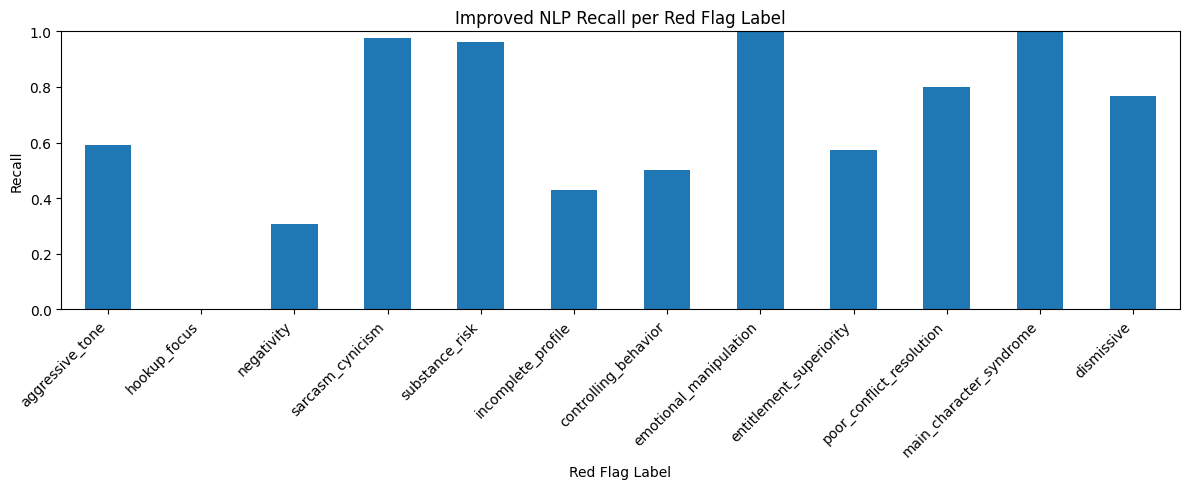

In [13]:
plt.figure(figsize=(12, 5))
per_label_report["recall"].plot(kind="bar")
plt.title("Improved NLP Recall per Red Flag Label")
plt.xlabel("Red Flag Label")
plt.ylabel("Recall")
plt.ylim(0, 1)
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

## 11. Inference function for testing inside this notebook

Notebook 05 will load the saved model artifacts. This helper is just for quick checks in Notebook 02.

In [14]:
def run_nlp_inference(profile_text):
    classifier = tfidf_logreg_model.named_steps["classifier"]
    tfidf = tfidf_logreg_model.named_steps["tfidf"]
    text_features = tfidf.transform([str(profile_text)])

    results = {}
    detected_flags = []

    for label, estimator in zip(label_columns, classifier.estimators_):
        probability = float(estimator.predict_proba(text_features)[0][1])
        threshold = float(custom_thresholds.get(label, 0.5))
        predicted = int(probability >= threshold)

        matches = keyword_rule_matches(profile_text, keyword_rules.get(label, []))

        results[label] = {
            "probability": round(probability, 4),
            "threshold": threshold,
            "predicted": predicted,
            "matched_rules": matches,
            "description": label_descriptions.get(label, ""),
        }
        if predicted:
            detected_flags.append(label)

    return {
        "module": "Improved TF-IDF multi-label NLP model",
        "detected_flags": detected_flags,
        "label_scores": results,
    }

## 12. Test with toxic demo profiles

These examples should now trigger the new labels.

In [15]:
toxic_demo_bio = """
I'm not like everyone else on here. I am always right.
Silent treatment is a must for the other party to learn from their mistakes on their own.
It is frustrating when people do not know my interests because it shows they are not observant.
I keep distance from people who wronged me because they do not need to be in my life once they hurt my feelings.
People are too sensitive when they complain about my standards.
"""

result = run_nlp_inference(toxic_demo_bio)
result["detected_flags"]

['emotional_manipulation',
 'entitlement_superiority',
 'poor_conflict_resolution']

In [16]:
pd.DataFrame(result["label_scores"]).T.sort_values("probability", ascending=False)[[
    "probability", "threshold", "predicted", "matched_rules", "description"
]]

,probability,threshold,predicted,matched_rules,description
emotional_manipulation,0.9998,0.25,1,"[\bsilent treatment\b, \bto learn from their m...","Silent treatment, guilt, emotional punishment,..."
poor_conflict_resolution,0.9965,0.1,1,"[\bwronged me\b, \bhurt my feelings\b, \bkeep ...","Cutting people off, refusing communication, re..."
entitlement_superiority,0.7451,0.3,1,[\bnot like everyone else\b],"Self-important, superior, dismissive, or 'peop..."
main_character_syndrome,0.3473,0.35,0,[],Self-centred profile framing where the person ...
aggressive_tone,0.0973,0.1,0,[],"Harsh, hostile, demanding, or insulting wording."
sarcasm_cynicism,0.0181,0.15,0,[],"Sarcastic, dismissive, or cynical tone."
dismissive,0.0111,0.1,0,[\btoo sensitive\b],"Invalidating, belittling, or contemptuous word..."
negativity,0.0057,0.1,0,[],"Pessimistic, bitter, cynical, or emotionally n..."
controlling_behavior,0.0031,0.1,0,"[\bi am always right\b, \balways right\b]","Language suggesting control, obedience, punish..."
substance_risk,0.0014,0.1,0,[],"Heavy drinking, smoking, drugs, or party-heavy..."


In [17]:
main_character_test = """
I am the main character. You are applying for a role in my life.
Keep me entertained, fit my aesthetic, and do not be a boring side character.
"""

main_character_result = run_nlp_inference(main_character_test)
pd.DataFrame(main_character_result["label_scores"]).T.sort_values("probability", ascending=False)[[
    "probability", "threshold", "predicted", "matched_rules", "description"
]].head(8)

,probability,threshold,predicted,matched_rules,description
entitlement_superiority,0.9997,0.3,1,[],"Self-important, superior, dismissive, or 'peop..."
main_character_syndrome,0.9989,0.35,1,"[\bi am the main character\b, \bkeep me entert...",Self-centred profile framing where the person ...
controlling_behavior,0.0511,0.1,0,[],"Language suggesting control, obedience, punish..."
emotional_manipulation,0.0242,0.25,0,[],"Silent treatment, guilt, emotional punishment,..."
poor_conflict_resolution,0.0116,0.1,0,[],"Cutting people off, refusing communication, re..."
aggressive_tone,0.0089,0.1,0,[],"Harsh, hostile, demanding, or insulting wording."
negativity,0.005,0.1,0,[],"Pessimistic, bitter, cynical, or emotionally n..."
sarcasm_cynicism,0.0046,0.15,0,[],"Sarcastic, dismissive, or cynical tone."


In [18]:
dismissive_test = """
People are too sensitive. If you overreact, that is your problem.
I do not care about emotional baggage, so get over it and deal with it.
"""

dismissive_result = run_nlp_inference(dismissive_test)
pd.DataFrame(dismissive_result["label_scores"]).T.sort_values("probability", ascending=False)[[
    "probability", "threshold", "predicted", "matched_rules", "description"
]].head(8)

,probability,threshold,predicted,matched_rules,description
poor_conflict_resolution,0.9983,0.1,1,[],"Cutting people off, refusing communication, re..."
dismissive,0.9958,0.1,1,"[\btoo sensitive\b, \bget over it\b, \bdeal wi...","Invalidating, belittling, or contemptuous word..."
aggressive_tone,0.9848,0.1,1,[],"Harsh, hostile, demanding, or insulting wording."
main_character_syndrome,0.0311,0.35,0,[],Self-centred profile framing where the person ...
entitlement_superiority,0.0268,0.3,0,[],"Self-important, superior, dismissive, or 'peop..."
emotional_manipulation,0.0161,0.25,0,[],"Silent treatment, guilt, emotional punishment,..."
sarcasm_cynicism,0.0151,0.15,0,[],"Sarcastic, dismissive, or cynical tone."
negativity,0.0136,0.1,0,[],"Pessimistic, bitter, cynical, or emotionally n..."


## 13. Save improved model artifacts

These filenames intentionally match what Notebook 05 already loads.

In [19]:
joblib.dump(tfidf_logreg_model, MODELS_DIR / "nlp_tfidf_logreg_model.pkl")
joblib.dump(label_columns, MODELS_DIR / "nlp_label_columns.pkl")
joblib.dump(custom_thresholds, MODELS_DIR / "nlp_custom_thresholds.pkl")
joblib.dump(label_descriptions, MODELS_DIR / "nlp_label_descriptions.pkl")
joblib.dump(keyword_rules, MODELS_DIR / "nlp_keyword_rules.pkl")

per_label_report.to_csv(REPORTS_DIR / "nlp_per_label_classification_report.csv")
overall_metrics.to_csv(REPORTS_DIR / "nlp_overall_metrics.csv", index=False)
confusion_summary_df.to_csv(REPORTS_DIR / "nlp_confusion_summary.csv", index=False)
threshold_df.to_csv(REPORTS_DIR / "nlp_thresholds_tuned.csv", index=False)
training_df[label_columns + ["model_text", "is_synthetic"]].to_csv(REPORTS_DIR / "nlp_training_data_augmented_preview.csv", index=False)

print("Improved NLP model saved successfully.")
print("Saved labels:", label_columns)
print("Saved thresholds:", custom_thresholds)

Improved NLP model saved successfully.
Saved labels: ['aggressive_tone', 'hookup_focus', 'negativity', 'sarcasm_cynicism', 'substance_risk', 'incomplete_profile', 'controlling_behavior', 'emotional_manipulation', 'entitlement_superiority', 'poor_conflict_resolution', 'main_character_syndrome', 'dismissive']
Saved thresholds: {'aggressive_tone': 0.1, 'hookup_focus': 0.5, 'negativity': 0.1, 'sarcasm_cynicism': 0.15, 'substance_risk': 0.1, 'incomplete_profile': 0.45, 'controlling_behavior': 0.1, 'emotional_manipulation': 0.25, 'entitlement_superiority': 0.3, 'poor_conflict_resolution': 0.1, 'main_character_syndrome': 0.35, 'dismissive': 0.1}


## 14. Optional Notebook 05 update

Notebook 05 already loads `nlp_label_columns.pkl`, so it will see the new labels. However, if Notebook 05 still has an old hardcoded `label_descriptions` dictionary, replace it with the dictionary below.

In [20]:
label_descriptions

{'aggressive_tone': 'Harsh, hostile, demanding, or insulting wording.',
 'hookup_focus': 'Strong focus on casual hookups or non-committal intent.',
 'negativity': 'Pessimistic, bitter, cynical, or emotionally negative statements.',
 'sarcasm_cynicism': 'Sarcastic, dismissive, or cynical tone.',
 'substance_risk': 'Heavy drinking, smoking, drugs, or party-heavy lifestyle.',
 'incomplete_profile': 'Low-effort profile with very little useful information.',
 'controlling_behavior': 'Language suggesting control, obedience, punishment, or dominance over a partner.',
 'emotional_manipulation': 'Silent treatment, guilt, emotional punishment, testing, or conditional affection.',
 'entitlement_superiority': "Self-important, superior, dismissive, or 'people must impress me' framing.",
 'poor_conflict_resolution': 'Cutting people off, refusing communication, revenge, blame, or inability to resolve conflict maturely.',
 'main_character_syndrome': 'Self-centred profile framing where the person treat